In [1]:
import os
os.chdir("/home/youngjins/project/belief_trading/")

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
import pandas as pd
from IPython.display import HTML
from typing import Dict, List

# 스타일 설정
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

In [2]:

results_base = "./results/exp2/"
experiment_date = "20250612_0159"
file_name = "L0B_vs_L1S_learning"  

# 결과 파일 로드
def load_experiment_results(file_path: str) -> Dict:
    """실험 결과 파일 로드"""
    with open(file_path, 'r') as f:
        results = json.load(f)
    return results

# 최신 결과 디렉토리 찾기
def find_latest_result_dir() -> str:
    """가장 최근 결과 디렉토리 찾기"""
    if os.path.exists(results_base):
        dirs = [d for d in os.listdir(results_base) if os.path.isdir(os.path.join(results_base, d))]
        if dirs:
            latest_dir = sorted(dirs)[-1]
            return os.path.join(results_base, latest_dir)
    
    # Fallback: 직접 경로 지정
    return os.path.join(result_dir, experiment_date) # 실제 경로로 수정 필요

# 파일 로드
result_dir = find_latest_result_dir()
file_path = os.path.join(result_dir, file_name, ".json")

print(f"로딩 파일: {file_path}")
results = load_experiment_results(file_path)

print(f"실험 정보:")
print(f"- 구매자 레벨: {results['buyer_level']}")
print(f"- 판매자 레벨: {results['seller_level']}")
print(f"- 실제 선호도: {results['true_preference']}")
print(f"- 총 게임 수: {len(results['games'])}")
print(f"- 수렴 여부: {results['convergence_info']['converged']}")
print(f"- 최저 손실: {results['convergence_info']['best_loss']:.6f}")
print(f"- 최종 손실: {results['convergence_info']['final_loss']:.6f}")

로딩 파일: ./results/exp2/20250612_0159/L0B_vs_L1S_learning.json
실험 정보:
- 구매자 레벨: 0
- 판매자 레벨: 1
- 실제 선호도: [7.0, 3.0]
- 총 게임 수: 1000
- 수렴 여부: False
- 최저 손실: 0.204846
- 최종 손실: 0.211311


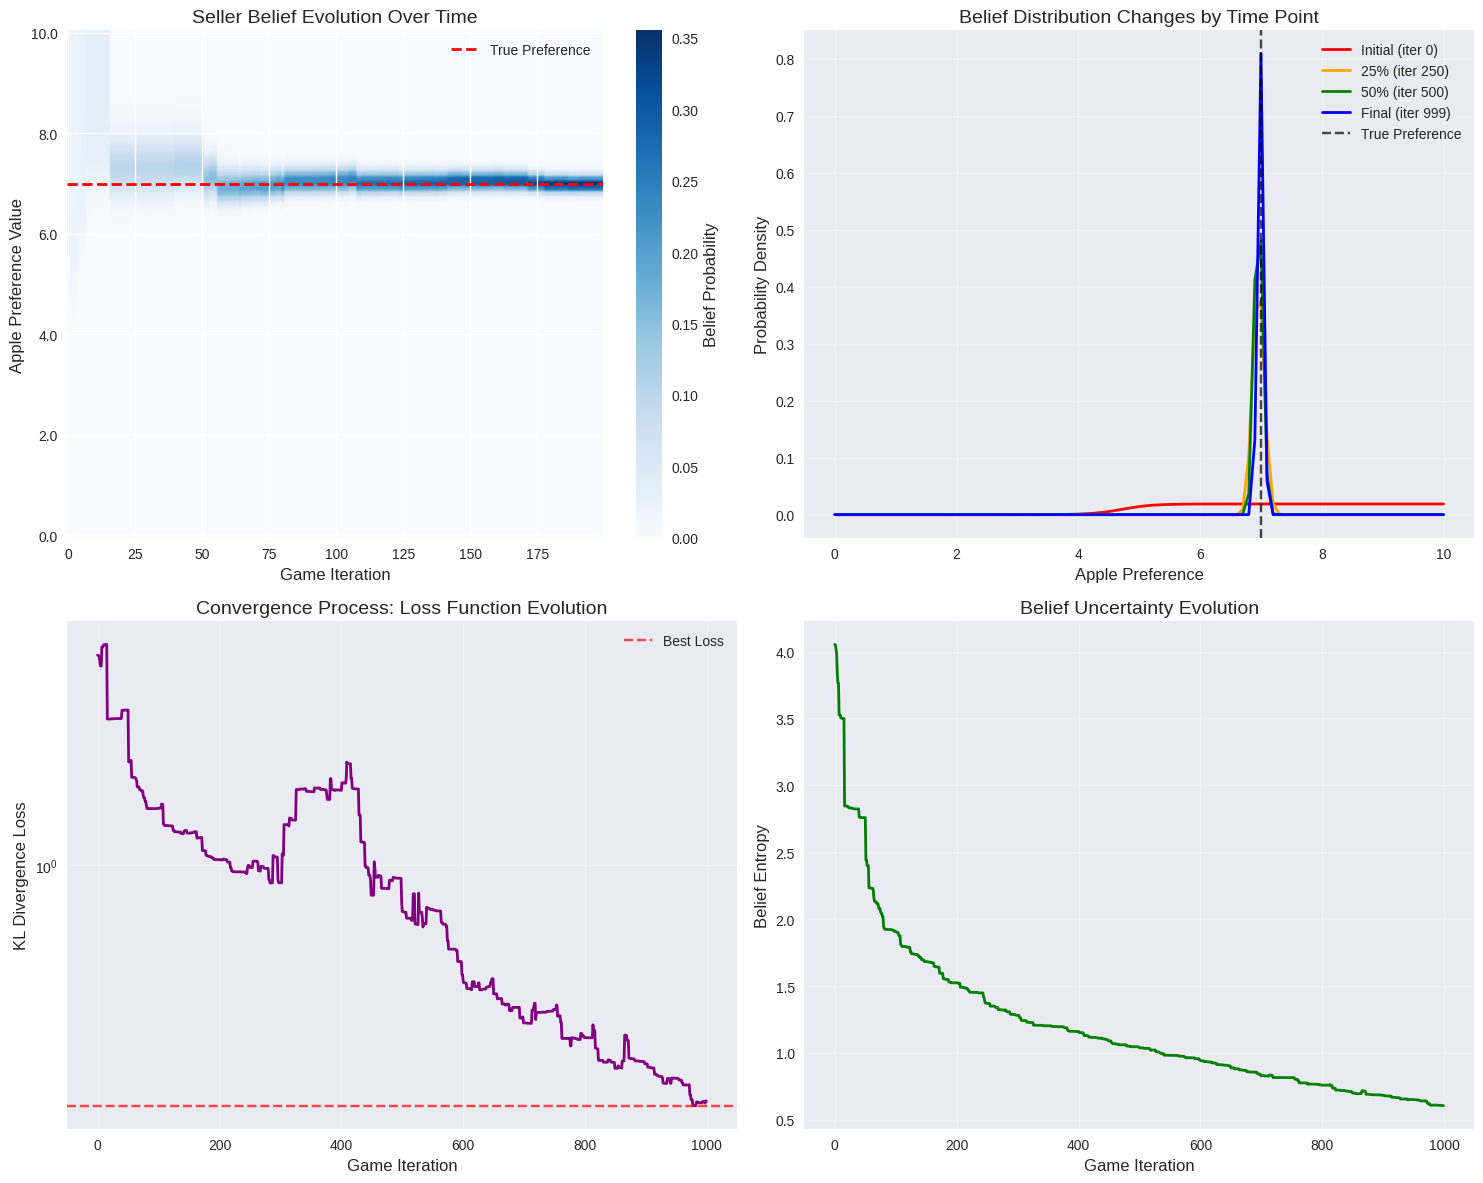

In [3]:
# 1. Seller belief evolution over time visualization

def extract_belief_evolution(results: Dict) -> tuple:
    """Extract belief evolution across games"""
    games = results['games']
    true_preference = np.array(results['true_preference'])
    
    iterations = []
    beliefs = []
    losses = []
    
    # Create preference grid (101 points)
    preference_grid = np.linspace(0, 10, 101)
    true_apple_pref = true_preference[0]
    
    for game in games:
        iterations.append(game['iteration'])
        beliefs.append(np.array(game['seller_belief']))
        losses.append(game['current_loss'])
    
    return iterations, beliefs, losses, preference_grid, true_apple_pref

iterations, beliefs, losses, preference_grid, true_apple_pref = extract_belief_evolution(results)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1-1: Belief distribution evolution over time (heatmap)
ax1 = axes[0, 0]
belief_matrix = np.array(beliefs[:min(200, len(beliefs))]).T  # First 200 only
im = ax1.imshow(belief_matrix, aspect='auto', origin='lower', cmap='Blues')
ax1.set_xlabel('Game Iteration')
ax1.set_ylabel('Apple Preference Value')
ax1.set_title('Seller Belief Evolution Over Time')

# Y-axis ticks
y_ticks = np.arange(0, len(preference_grid), 20)
ax1.set_yticks(y_ticks)
ax1.set_yticklabels([f'{preference_grid[i]:.1f}' for i in y_ticks])

# True preference line
true_idx = np.argmin(np.abs(preference_grid - true_apple_pref))
ax1.axhline(y=true_idx, color='red', linestyle='--', linewidth=2, label='True Preference')
ax1.legend()

plt.colorbar(im, ax=ax1, label='Belief Probability')

# 1-2: Belief distributions at specific time points
ax2 = axes[0, 1]
snapshots = [0, len(beliefs)//4, len(beliefs)//2, len(beliefs)-1]
colors = ['red', 'orange', 'green', 'blue']
labels = ['Initial', '25%', '50%', 'Final']

for i, (snapshot, color, label) in enumerate(zip(snapshots, colors, labels)):
    if snapshot < len(beliefs):
        ax2.plot(preference_grid, beliefs[snapshot], color=color, label=f'{label} (iter {iterations[snapshot]})', linewidth=2)

ax2.axvline(x=true_apple_pref, color='black', linestyle='--', alpha=0.7, label='True Preference')
ax2.set_xlabel('Apple Preference')
ax2.set_ylabel('Probability Density')
ax2.set_title('Belief Distribution Changes by Time Point')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 1-3: Loss function evolution
ax3 = axes[1, 0]
ax3.plot(iterations, losses, linewidth=2, color='purple')
ax3.set_xlabel('Game Iteration')
ax3.set_ylabel('KL Divergence Loss')
ax3.set_title('Convergence Process: Loss Function Evolution')
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')

# Show convergence threshold
convergence_threshold = results['convergence_info']['best_loss']
ax3.axhline(y=convergence_threshold, color='red', linestyle='--', alpha=0.7, label='Best Loss')
ax3.legend()

# 1-4: Belief entropy evolution
ax4 = axes[1, 1]
entropies = [-np.sum(belief * np.log(belief + 1e-10)) for belief in beliefs]
ax4.plot(iterations, entropies, linewidth=2, color='green')
ax4.set_xlabel('Game Iteration')
ax4.set_ylabel('Belief Entropy')
ax4.set_title('Belief Uncertainty Evolution')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

믿음 변화 애니메이션 생성 중...
애니메이션이 './results/exp2/20250612_0159/belief_evolution.gif'로 저장되었습니다.


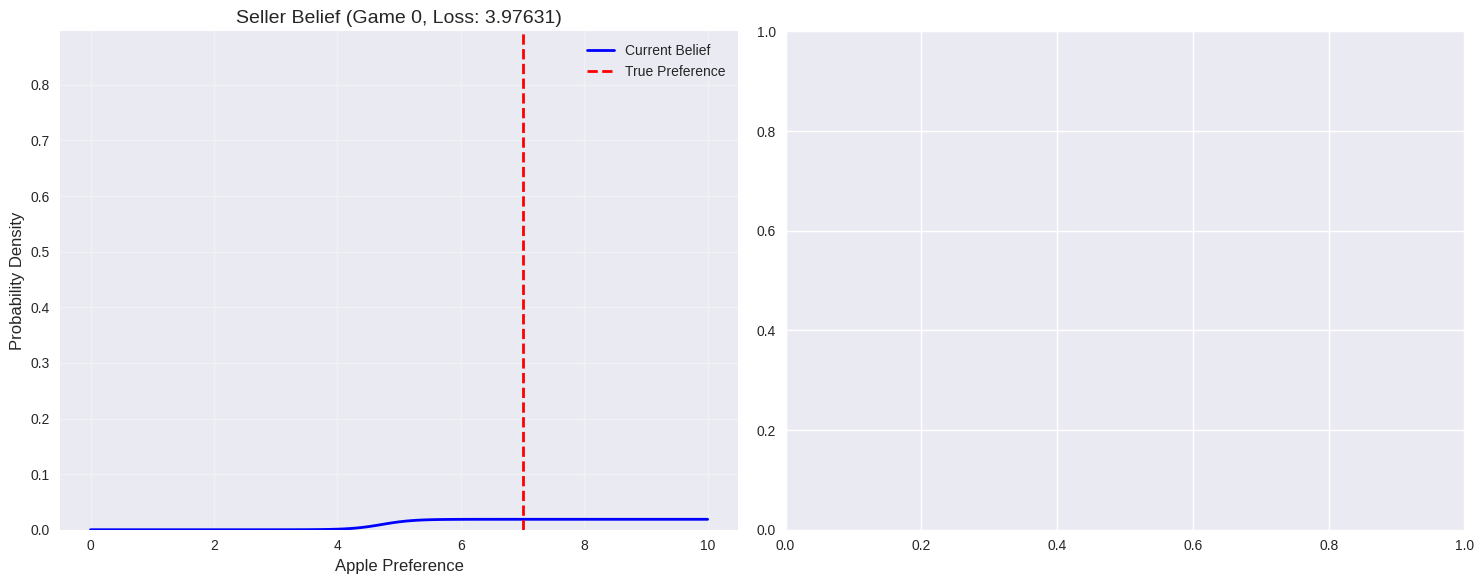

In [4]:
# 4. 애니메이션으로 믿음 변화 시각화 (선택사항)

def create_belief_animation(iterations, beliefs, preference_grid, true_apple_pref):
    """믿음 변화를 애니메이션으로 시각화"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 애니메이션할 데이터 준비 (너무 많으면 샘플링)
    max_frames = 100
    if len(beliefs) > max_frames:
        step = len(beliefs) // max_frames
        sampled_iterations = iterations[::step]
        sampled_beliefs = beliefs[::step]
    else:
        sampled_iterations = iterations
        sampled_beliefs = beliefs
    
    def animate(frame):
        ax1.clear()
        ax2.clear()
        
        current_belief = sampled_beliefs[frame]
        current_iter = sampled_iterations[frame]
        
        # 현재 믿음 분포
        ax1.plot(preference_grid, current_belief, 'b-', linewidth=2, label='Current Belief')
        ax1.axvline(x=true_apple_pref, color='red', linestyle='--', linewidth=2, label='True Preference')
        ax1.set_xlabel('Apple Preference')
        ax1.set_ylabel('Probability Density')
        ax1.set_title(f'Seller Belief (Game {current_iter}, Loss: {losses[current_iter]:.5f})')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(0, max([max(b) for b in sampled_beliefs]) * 1.1)
        
        # 누적 믿음 히스토리 (히트맵)
        if frame > 0:
            history_matrix = np.array(sampled_beliefs[:frame+1]).T
            im = ax2.imshow(history_matrix, aspect='auto', origin='lower', cmap='Blues')
            ax2.set_xlabel('Game Iteration')
            ax2.set_ylabel('Apple Preference')
            ax2.set_title('Belief Evolution History')
            
            # Y축 눈금
            y_ticks = np.arange(0, len(preference_grid), 20)
            ax2.set_yticks(y_ticks)
            ax2.set_yticklabels([f'{preference_grid[i]:.1f}' for i in y_ticks])
            
            # True preference 라인
            true_idx = np.argmin(np.abs(preference_grid - true_apple_pref))
            ax2.axhline(y=true_idx, color='red', linestyle='--', linewidth=1, alpha=0.7)
        
        plt.tight_layout()
    
    anim = FuncAnimation(fig, animate, frames=len(sampled_beliefs), 
                        interval=200, blit=False, repeat=True)
    
    return anim

# 애니메이션 생성 (시간이 오래 걸릴 수 있음)
print("믿음 변화 애니메이션 생성 중...")
belief_anim = create_belief_animation(iterations, beliefs, preference_grid, true_apple_pref)

# 애니메이션 저장 (선택사항)
belief_anim.save(f'{result_dir}/{file_name}_anima.gif', writer='pillow', fps=5)
print(f"애니메이션이 '{result_dir}/{file_name}_anima.gif'로 저장되었습니다.")

# Jupyter에서 애니메이션 표시
HTML(belief_anim.to_jshtml())

INFO:simulate_synthetic_online:온라인 학습 시작: 구매자 L0 vs 판매자 L1
INFO:simulate_synthetic_online:반복 0: 손실 = 4.016647, 최고 = 4.016647


Temperature 분석 시작...
Beta = 0.50 실험 중...


INFO:simulate_synthetic_online:반복 100: 손실 = 2.600568, 최고 = 2.383732
INFO:simulate_synthetic_online:반복 200: 손실 = 2.756371, 최고 = 2.184154
INFO:simulate_synthetic_online:실험 완료. 최종 손실: 2.109122
INFO:simulate_synthetic_online:온라인 학습 시작: 구매자 L0 vs 판매자 L1
INFO:simulate_synthetic_online:반복 0: 손실 = 3.920904, 최고 = 3.920904


  수렴: False, 반복 횟수: 300, 최종 손실: 2.109122
Beta = 1.00 실험 중...


INFO:simulate_synthetic_online:반복 100: 손실 = 1.821662, 최고 = 1.755244
INFO:simulate_synthetic_online:반복 200: 손실 = 1.282205, 최고 = 1.269908
INFO:simulate_synthetic_online:실험 완료. 최종 손실: 1.059738
INFO:simulate_synthetic_online:온라인 학습 시작: 구매자 L0 vs 판매자 L1
INFO:simulate_synthetic_online:반복 0: 손실 = 4.607416, 최고 = 4.607416


...

  수렴: False, 반복 횟수: 300, 최종 손실: 1.195748
Beta = 4.00 실험 중...


INFO:simulate_synthetic_online:반복 100: 손실 = 0.907687, 최고 = 0.907687
INFO:simulate_synthetic_online:반복 200: 손실 = 1.490357, 최고 = 0.905837
INFO:simulate_synthetic_online:실험 완료. 최종 손실: 0.945844
INFO:simulate_synthetic_online:온라인 학습 시작: 구매자 L0 vs 판매자 L1
INFO:simulate_synthetic_online:반복 0: 손실 = 3.820034, 최고 = 3.820034


  수렴: False, 반복 횟수: 300, 최종 손실: 0.945844
Beta = 5.00 실험 중...


INFO:simulate_synthetic_online:반복 100: 손실 = 4.557195, 최고 = 1.480004
INFO:simulate_synthetic_online:반복 200: 손실 = 3.962442, 최고 = 1.480004
INFO:simulate_synthetic_online:실험 완료. 최종 손실: 3.027568


  수렴: False, 반복 횟수: 300, 최종 손실: 3.027568
Temperature 분석 완료!


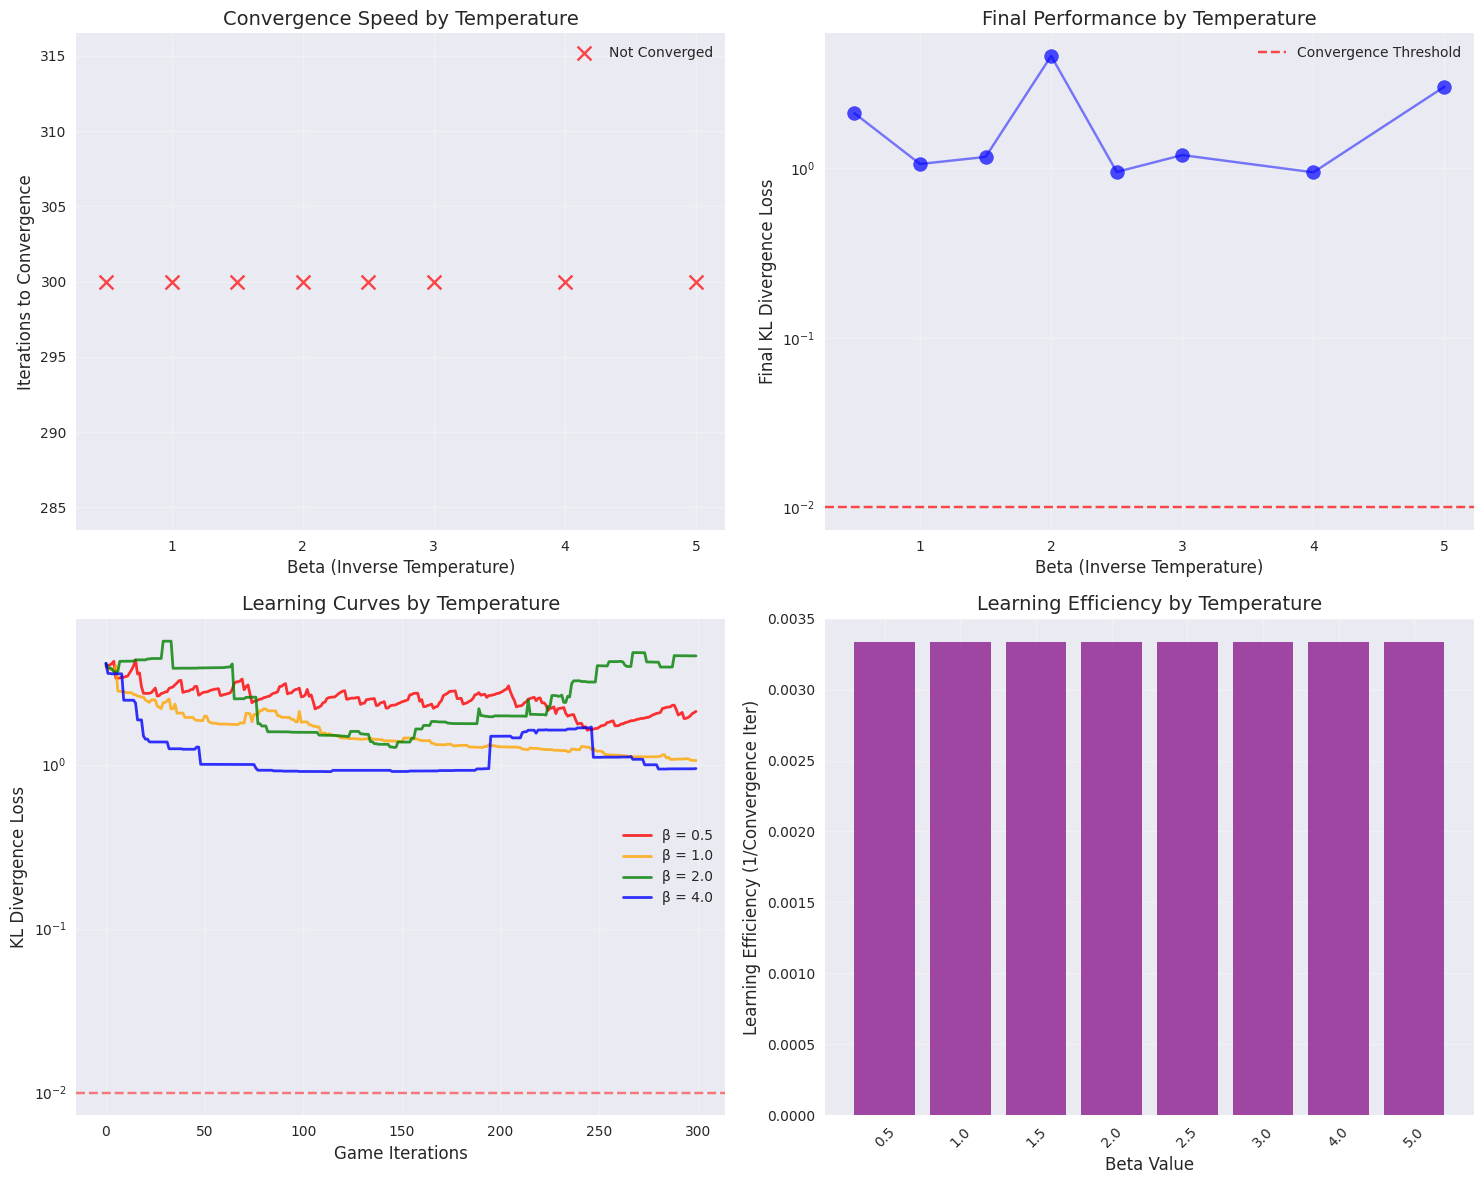


=== Temperature 분석 결과 요약 ===
 Beta  Temperature (1/Beta) 수렴 여부  수렴 반복 횟수    최종 손실
  0.5              2.000000     X       300 2.109122
  1.0              1.000000     X       300 1.059738
  1.5              0.666667     X       300 1.166405
  2.0              0.500000     X       300 4.596941
  2.5              0.400000     X       300 0.951251
  3.0              0.333333     X       300 1.195748
  4.0              0.250000     X       300 0.945844
  5.0              0.200000     X       300 3.027568


In [9]:
# 2. Temperature(Beta) 값에 따른 수렴 속도 분석
# 다양한 beta 값으로 실험을 실행하고 수렴 속도 비교

import sys
sys.path.append('./script/exp2/')

# simulate_synthetic_online.py에서 필요한 클래스들 import
from simulate_synthetic_online import (
    OnlineLearningEnvironment, 
    convert_arrays_to_lists,
    DEFAULT_BETA
)

def run_temperature_analysis(true_preference: np.ndarray, 
                           beta_values: List[float],
                           max_iterations: int = 500,
                           convergence_threshold: float = 0.01) -> Dict:
    """다양한 temperature 값에 대한 수렴 분석"""
    
    results = {
        'beta_values': beta_values,
        'convergence_iterations': [],
        'final_losses': [],
        'loss_histories': [],
        'converged_flags': []
    }
    
    for beta in beta_values:
        print(f"Beta = {beta:.2f} 실험 중...")
        
        # 환경 생성
        env = OnlineLearningEnvironment(
            buyer_level=0,
            seller_level=1, 
            true_preference=true_preference,
            beta=beta,
            window_size=50
        )
        
        # 실험 실행
        experiment_results = env.run_learning_experiment(max_iterations)
        
        # 결과 저장
        convergence_info = experiment_results['convergence_info']
        converged = convergence_info['converged']
        final_loss = convergence_info['final_loss']
        loss_history = convergence_info['all_losses']
        
        # 수렴까지의 반복 횟수 계산
        if converged:
            # 임계값 이하로 떨어진 첫 번째 지점 찾기
            convergence_iter = next((i for i, loss in enumerate(loss_history) 
                                   if loss < convergence_threshold), max_iterations)
        else:
            convergence_iter = max_iterations
        
        results['convergence_iterations'].append(convergence_iter)
        results['final_losses'].append(final_loss)
        results['loss_histories'].append(loss_history)
        results['converged_flags'].append(converged)
        
        print(f"  수렴: {converged}, 반복 횟수: {convergence_iter}, 최종 손실: {final_loss:.6f}")
    
    return results

# Temperature 분석 실행
true_preference = np.array(results['true_preference'])
beta_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]  # 다양한 temperature 값

print("Temperature 분석 시작...")
temp_results = run_temperature_analysis(true_preference, beta_values, max_iterations=300)
print("Temperature 분석 완료!")

# Temperature 분석 결과 시각화

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2-1: Beta 값에 따른 수렴 속도
ax1 = axes[0, 0]
convergence_iters = temp_results['convergence_iterations']
beta_vals = temp_results['beta_values']
converged_flags = temp_results['converged_flags']

# 수렴한 경우와 수렴하지 않은 경우 구분
converged_betas = [b for b, c in zip(beta_vals, converged_flags) if c]
converged_iters = [i for i, c in zip(convergence_iters, converged_flags) if c]
not_converged_betas = [b for b, c in zip(beta_vals, converged_flags) if not c]
not_converged_iters = [i for i, c in zip(convergence_iters, converged_flags) if not c]

if converged_betas:
    ax1.scatter(converged_betas, converged_iters, color='green', s=100, label='Converged', alpha=0.7)
    ax1.plot(converged_betas, converged_iters, color='green', alpha=0.5, linestyle='-')

if not_converged_betas:
    ax1.scatter(not_converged_betas, not_converged_iters, color='red', s=100, label='Not Converged', alpha=0.7, marker='x')

ax1.set_xlabel('Beta (Inverse Temperature)')
ax1.set_ylabel('Iterations to Convergence')
ax1.set_title('Convergence Speed by Temperature')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2-2: Beta 값에 따른 최종 손실
ax2 = axes[0, 1]
final_losses = temp_results['final_losses']
ax2.scatter(beta_vals, final_losses, color='blue', s=100, alpha=0.7)
ax2.plot(beta_vals, final_losses, color='blue', alpha=0.5, linestyle='-')
ax2.set_xlabel('Beta (Inverse Temperature)')
ax2.set_ylabel('Final KL Divergence Loss')
ax2.set_title('Final Performance by Temperature')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# 수렴 임계값 표시
ax2.axhline(y=0.01, color='red', linestyle='--', alpha=0.7, label='Convergence Threshold')
ax2.legend()

# 2-3: 손실 함수 변화 비교 (선택된 beta 값들)
ax3 = axes[1, 0]
selected_betas = [0.5, 1.0, 2.0, 4.0]  # 몇 개만 선택해서 시각화
colors = ['red', 'orange', 'green', 'blue']

for beta, color in zip(selected_betas, colors):
    if beta in beta_vals:
        idx = beta_vals.index(beta)
        loss_history = temp_results['loss_histories'][idx]
        iterations_range = range(len(loss_history))
        ax3.plot(iterations_range, loss_history, color=color, linewidth=2, 
                label=f'β = {beta}', alpha=0.8)

ax3.set_xlabel('Game Iterations')
ax3.set_ylabel('KL Divergence Loss')
ax3.set_title('Learning Curves by Temperature')
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 수렴 임계값 표시
ax3.axhline(y=0.01, color='red', linestyle='--', alpha=0.5)

# 2-4: Temperature 효과 해석
ax4 = axes[1, 1]

# 효율성 지표 계산 (수렴 속도의 역수)
efficiency = [1.0/max(1, iter_count) for iter_count in convergence_iters]
ax4.bar(range(len(beta_vals)), efficiency, color='purple', alpha=0.7)
ax4.set_xlabel('Beta Value')
ax4.set_ylabel('Learning Efficiency (1/Convergence Iter)')
ax4.set_title('Learning Efficiency by Temperature')
ax4.set_xticks(range(len(beta_vals)))
ax4.set_xticklabels([f'{b:.1f}' for b in beta_vals], rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 결과 요약 테이블
print("\n=== Temperature 분석 결과 요약 ===")
df_summary = pd.DataFrame({
    'Beta': beta_vals,
    'Temperature (1/Beta)': [1/b for b in beta_vals],
    '수렴 여부': ['O' if c else 'X' for c in converged_flags],
    '수렴 반복 횟수': convergence_iters,
    '최종 손실': [f"{loss:.6f}" for loss in final_losses]
})

print(df_summary.to_string(index=False))

In [7]:
# 3. 결과 해석 및 인사이트

print("\n=== 실험 결과 해석 ===")

# 최적 beta 값 찾기
if converged_betas:
    best_beta_idx = converged_iters.index(min(converged_iters))
    best_beta = converged_betas[best_beta_idx]
    best_convergence = converged_iters[best_beta_idx]
    
    print(f"\n1. 최적 Temperature 설정:")
    print(f"   - 최적 β 값: {best_beta}")
    print(f"   - 최적 Temperature (1/β): {1/best_beta:.3f}")
    print(f"   - 수렴까지 필요한 게임 수: {best_convergence}")

# Temperature 효과 분석
low_beta_performance = np.mean([loss for beta, loss in zip(beta_vals, final_losses) if beta <= 1.5])
high_beta_performance = np.mean([loss for beta, loss in zip(beta_vals, final_losses) if beta >= 3.0])

print(f"\n2. Temperature 효과 분석:")
print(f"   - 낮은 β (높은 temp) 평균 성능: {low_beta_performance:.6f}")
print(f"   - 높은 β (낮은 temp) 평균 성능: {high_beta_performance:.6f}")

if low_beta_performance > high_beta_performance:
    print(f"   → 높은 temperature(탐험적 정책)가 더 나은 성능을 보임")
else:
    print(f"   → 낮은 temperature(결정적 정책)가 더 나은 성능을 보임")

# 수렴 패턴 분석
convergence_rate = sum(converged_flags) / len(converged_flags)
print(f"\n3. 수렴 패턴:")
print(f"   - 전체 수렴률: {convergence_rate:.1%}")
print(f"   - 수렴한 설정 수: {sum(converged_flags)}/{len(converged_flags)}")

if convergence_rate < 1.0:
    non_converged_betas = [b for b, c in zip(beta_vals, converged_flags) if not c]
    print(f"   - 수렴하지 않은 β 값들: {non_converged_betas}")

print(f"\n4. 권장사항:")
if converged_betas:
    print(f"   - 빠른 수렴을 위해서는 β = {best_beta} 사용 권장")
    print(f"   - 이는 구매자의 행동에 적절한 노이즈를 제공하여")
    print(f"   - 판매자가 효과적으로 선호도를 학습할 수 있게 함")
else:
    print(f"   - 테스트한 범위에서 수렴하는 설정이 없음")
    print(f"   - 더 낮은 β 값이나 더 많은 반복이 필요할 수 있음")


=== 실험 결과 해석 ===

2. Temperature 효과 분석:
   - 낮은 β (높은 temp) 평균 성능: 1.428826
   - 높은 β (낮은 temp) 평균 성능: 1.807777
   → 낮은 temperature(결정적 정책)가 더 나은 성능을 보임

3. 수렴 패턴:
   - 전체 수렴률: 0.0%
   - 수렴한 설정 수: 0/8
   - 수렴하지 않은 β 값들: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]

4. 권장사항:
   - 테스트한 범위에서 수렴하는 설정이 없음
   - 더 낮은 β 값이나 더 많은 반복이 필요할 수 있음
